In [1]:
import networkx as nx
import random
import numpy as np
import math
import heapq
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from itertools import combinations
import sys

# Equitably Coloring Planar and Outerplanar Graphs

## 1. Introduction

This notebook is designed to accompany a recent paper (with the same title) by Cranston and Mahmoud.<br>
You can find the paper on arXiv at https://arxiv.org/abs/2509.16123

### 1.1 Math Background

An $s$-coloring $\varphi$ of a graph $G$ is a map $\varphi:V(G) \to [s]$.  (We write $[s]$ to denote $\{1,\ldots,s\}$.) We call $\varphi$ *proper* if $\varphi(v)\ne\varphi(w)$ for each edge $vw\in E(G)$.  And a proper $\varphi$ is *equitable* if each color class has the same size (within 1).  That is, $||\varphi^{-1}(i)| - |\varphi^{-1}(j)|| \le 1$ for all $i,j\in[s]$.  Equitable coloring has various applications, many of which center on the idea of assigning jobs to workers (or servers, or agents) and aiming to assign about the same number of jobs to each.

The introduction of the paper gives a more thorough literature review.  But now we turn to the paper's motivation.  Many very beautiful results in mathematics provide necessary and sufficient conditions for the existence of a certain object.  If a graph $G$ has an equitable $s$-coloring, then clearly each vertex must lie in an independent set of size at least $\lfloor n/s\rfloor$ (namely, its color class in the coloring).  We denote by $\alpha_x(F)$ the maximum size of an independent set in a graph $F$ containing some specified vertex $x$; when $F$ is clear from context, we simply write $\alpha_x$. Chang https://arxiv.org/abs/math/0407235 (and earlier Miyata, Tokunaga, and Kaneko) proved that if $G$ is a tree, or even a forest, then this obvious necessary condition is sufficient.

**Tree Theorem** [Chang]: Let $F$ be an $n$-vertex forest, and fix an integer $s \ge 3$.  Now $F$ is equitably $s$-colorable if and only if $\min_{x\in V(G)}\alpha_x \ge \lfloor n/s\rfloor$.

This result motivated the following question of Kierstead, Kostochka, and Xiang.  (A graph $G$ is *outerplanar* if it can be drawn in the plane with no edge crossings and with all vertices on the outer face.  Equivalently, the graph $G^+$ formed by adding a dominating vertex is planar.)

**Question** [KKX]: Is it true for every outerplanar graph $G$ and every integer $s \ge 3$ that $G$ is equitably $s$-colorable if and only if $\min_{x\in V(G)}\alpha_x \ge \lfloor n/s\rfloor$?

The first main result of our paper answers (mostly) this question.

**Main Theorem** [CM]: Fix $s\geqslant 6$, and let $G$ be outerplanar. If $\alpha_v \geqslant \lfloor n/s\rfloor$ for all $v\in V(G)$, 
then $G$ has an equitable $s$-coloring. The analogous statement is false for $s=3$ and open for $s\in\{4,5\}$.

The case $s=3$ is handled by constructing outerplanar ``near-triangulations'' (every face is a triangle but the outer one) that have
only one 3-coloring, up to permuting colors, and the color classes have size $n/2, n/4, n/4$.  We won't say any more about these constructions here. (But we will say a lot more about the Main Theorem below.)  Our next main result is the following.

**Planar Theorem** [CM]: Fix $s\geqslant 40$, and let $G$ be a planar graph. Let $w_0,w_1$ be its 2 vertices with
largest degrees, breaking ties arbitrarily. If there exist disjoint independent sets $I_0,I_1$ such that
$|I_0|= \lfloor n/s\rfloor$ and $|I_1|= \lfloor(n+1)/s\rfloor$ and $w_0,w_1 \in I_0\cup I_1$, then $G$ has an equitable $s$-coloring.  (In fact, this sufficient condition is also necessary.)

The reason this condition is necessary is because of the graph $(K_2 \vee P_{s^2}) + sK_1$, formed from the join of $K_2$ and $P_{s^2}$
by adding $s$ isolated vertices.  Each of the high degree vertices is in a big independent set.  But these high degree vertices are 
adjacent, and we do not have enough isolated vertices to make (big enough) *disjoint* independent sets containing both of them.

**Proof sketch(es)**: All of the proofs in the paper follow the same approach.  We use induction *on s*, the number of colors.
The key point is that if remove an independent set $I_s$ of order $\lfloor n/s\rfloor$ (or $\lceil n/s\rceil$) and equitably $(s-1)$-color
the smaller graph, then we can add $I_s$ as the $s$th color class, to give an equitable $s$-coloring of the graph $G.$  So two points remain: (1) We must ensure that $G-I_s$ satisfies the hypothesis to be equitably $(s-1)$-colorable, by induction; and (2) we must handle the base case of the induction.  Perhaps surprisingly, (1) is typically fairly easy; but (2) requires a lot of work.  To handle (1) we choose $I_0$ to be an independent set of order $\lfloor n/s\rfloor$ that contains a vertex $w_0$ of maximum degree.  To handle (2), we will partition $V(G)$ into ``equitable'' forests (their orders differ by at most 1), and equitably color each forest by the Tree Theorem, above.  For the Main Theorem, we ourselves construct this equitable partition into forests.  But for the Planar Theorem, we rely on previous results to construct the partition for us.

We also prove a more general result for $d$-degenerate graphs.  But the number of colors required there is quite large; this makes our $d$-Degenerate Theorem less interesting for implementation, which is the focus of this notebook.  So here we won't discuss it further.



### 1.2 What this Notebook Does (and Doesn't Do)

The focus of this notebook is to show that the algorithms implicit in the paper can be implemented to efficiently work on graphs of 10,000 vertices or more.  In the paper, we say very little about algorithms.  But most of the proofs naturally give rise algorithms that run in time $O(sn)$, and that is what we implement here.

We note that both our Main Theorem and our Planar Theorem rely heavily on previous work, particularly to equitably color forests.  And our Planar Theorem also makes use of acyclic colorings with few colors.  A proper coloring is *acyclic* if the subgraph induced by every 2 color classes has no cycles.  Thus, to ultimately implement our own algorithms, we must first implement some version of these previous results.  Borodin proved (twice!) that every planar graph has an acyclic 5-coloring; and this is best possible.  But both of his papers proving this result are about 20 pages long, and one of them uses approximately 450 reducible configurations.  Implementing such a proof
is not our goal here.  So instead we fall back to an earlier result of Albertson and Berman: Every planar graph has an acyclic 7-coloring.
The proof of this result is still non-trivial, but it relies on only 4 types of reducible configurations, which makes it much more reasonable to implement.

We suspect that verifying the hypotheses of either the Main Theorem or the Planar Theorem is NP-hard.  (We haven't written a proof for either.  But it is well-known that maximum independent set is NP-hard, and this hardness result persists even when the input graph is required to be planar.)  Thus,...

**Warning**: We do not attempt to exactly answer the question of whether or not an input graph satisfies the hypothesis of either the Main Theorem or the Planar Theorem.  Rather, we use heuristics to search for the desired independent sets required by the theorems.  If our heuristics find the independent sets, then we use them to construct the desired equitable colorings.  Alternatively, we provide the option for the user to supply the required independent sets.

**Algorithm Correctness**: We do not provide here formal proofs of correctness.  The paper comes much closer to that with its proofs.  However, we make liberal use of ```assert``` statements to verify that the object returned by each algorithm possesses the claimed attributes.
For example, before returning an equitable coloring (of a planar graph) we use ```assert all(coloring[v] != coloring[w] for v,w in G.edges)``` to verify that the coloring is indeed *proper*.  So whenever an algorithm completes successfully, we have high confidence that the object returned is, in fact, what we claim it is.

## 2. Implementation Overview

### 2.1 Graph Representation and Key Features of Networkx

All graphs are encoded using `networkx`, which we import as `nx`.  So each graph has type `nx.Graph`.  For a graph `G`, most often we will use `G.nodes` and `G.edges`.  For planar graphs, we can ask `nx` for a plane embedding by `is_planar, embedding = nx.check_planarity(G)`.  Our algorithm to acyclically 7-color a planar graph relies crucially on this embedding.

### 2.2 Functions and Dependencies

This notebook has many functions, some of which are just used to build interesting test cases for various parts of the code implementing the core algorithms.  The table below gives an overview of some of the most important functions.  

For most of our functions, we use a 3-part naming scheme `part1_part2_part3` where `part3` describes the type of input, `part2` describes the type of output, and `part1` describes a key property of the output.  So `acyclic_color_planar` takes as input a *planar* graph, gives as output a *coloring*, and the key attribute of that coloring is that it is *acyclic*.  Similarly, `equi_color_forest` takes a forest (and a positive integer $s$) and returns an equitable $s$-coloring.  And `max_indSet_forest` takes a forest (and, optionally, a vertex $v$) and returns a maximum size independent set, containing $v$ if it is given.  A few functions depart from this naming scheme, such as `triangulate_planar` and `treeify_forest`, the latter of which returns a tree for which the input forest is a spanning subgraph.


| function name | input | output | used by | uses | notes |
| :------------ | :---- | :----- | :------ | :---- | :---- |
| `acyclic_color_planar` | planar graph | acyclic 7-coloring | `equi_forest_planar` | `triangulate_planar` ||
| `equi_color_forest` | forest, number $s$ of colors | equitable $s$-coloring |  | `treeify_forest` `min_equi_forest`||
| `equi_color_oplanar` | outerplanar graph, number $s$ of colors | equitable $s$-coloring |  | `equi_color_forest` `max_indSet_any` | |
| `equi_color_planar` | planar graph, number $s$ of colors | equitable $s$-coloring |  | `max_indSet_any` `equi_forest_planar` `equi_color_forest` | algorithm is *heuristic* (finding big ind. sets is hard); often works for fewer colors than required (but min of 20)|
| `equi_forest_oplanar` | outerplanar graph, number $s$ of colors | equipartition into $s$ forests |  | ||
| `equi_forest_planar` | planar graph, number $s$ of colors | equipartition into $s$ forests |  | `acyclic_color_planar` ||
| `greedy_color_any` | any graph $G$| proper $(d+1)$-coloring, when $G$ is $d$-degenerate | `max_indSet_any` | ||
| `max_indSet_any` | graph and (optional) $v$ | maximal independent set (containing $v$) | `equi_color_planar` `equi_color_oplanar` | `greedy_color_any` | algorithm is *heuristic* (set might not be *maximum*)|
| `max_indSet_forest` | forest $F$ and (optional) vertex $v$ | maximum independent set in $F$ (containing $v$) | ||  algorithm is *exact*|
| `min_equi_forest` | forest $F$ | min s s.t. F is equitably $s$-colorable | `equi_color_forest` | `max_indSet_forest` | |
| `treeify_forest` | forest $F$ | tree $T$ | `equi_color_forest` | |$T$ has $F$ as a spanning subgraph |
| `triangulate_planar` | planar graph | triangulated supergraph, vertex positions | `acyclic_color_planar` | | |

## 3. Preliminaries

### 3.1 6-Coloring Planar Graphs and 3-Coloring Outerplanar Graphs and Finding Big Independent Sets

The induction step (on $s$) used to prove both of our main results requires us to find a big independent set containing a specified vertex $v$.  Rather than doing anything fancy, it usually works to just delete $N[v]$, color the smaller graph with few colors, then take the biggest color class together with $v$, discarding vertices if needed, to reach an independent set of the prescribed size that contains $v$.
To make this precise, we recall that a graph $G$ is $d$*-degenerate*, for some positive integer $d$, if every subgraph $H$ of $G$ contains a vertex $v$ with $d_H(v)\leqslant d$.  The *degeneracy* of $G$ is the minimum $d$ such that $G$ is *$d$-degenerate*.

Every outerplanar graph with a triangle, or any odd cycle, requires 3 colors.  And because each outerplanar graph $G$ is 2-degerate, we get a very simple 3-coloring algorithm: delete a vertex v of degree at most 2, then 3-color the smaller graph $G-v$, and finally extend 
the coloring to $v$.
Since planar graphs are 5-degenerate, the same approach guarantees a 6-coloring.  Of course planar graphs are 4-colorable, but currently no known algorithm produces a 4-coloring in linear time.  5-coloring can be done in linear time, but the known algorithms are more involved than what we provide below for 6-coloring.

In [2]:
def degeneracy_order(G0):  # returns degeneracy of G, along with a vertex order witnessing this
    G = G0.copy()          # we're going to destroy the graph, but don't want to affect the input
    max_so_far = 0         # this will ultimately be the degeneracy of G
                           # we increase max_so_far each time we can't find any vertices of at most that degree
    low_degree = set()     # initial empty set of low degree vertices
    order = []

    while G.nodes:
        for v in G.nodes:  # add to set of low degree vertices 
            if G.degree(v) <= max_so_far:        
                low_degree.add(v)
    
        while low_degree:                           
            v = low_degree.pop()
            order.append(int(v))
            
            for w in G.neighbors(v):
                if G.degree(w) <= max_so_far+1:  # haven't deleted v yet  
                     low_degree.add(w)
            G.remove_node(v)
            
        if G.nodes:
            max_so_far+=1  # ran out of low degree vertices; increase the threshold, find more, keep going...
        
    return max_so_far, order 

In [3]:
def greedy_color(G, order):  # colors G greedily, considering vertices in the order given by order
                             # here order is just a list (of vertex names), and colors is a dictionary                          
    colors = {}
    for v in order:
        colors[v] = None
    for v in order:
        used = {colors[w] for w in G.neighbors(v)}
        mycolor = 0  # colors start from 0
        while (mycolor in used): 
            mycolor+=1 
        colors[v] = mycolor
    return colors

The next two functions are just *wrapper functions* for easy reference.  These are what we will use later on.

In [4]:
def greedy_color_any(G):  # returns a (d+1)-color for any d-degenerate graph; determines d itself
    my_order = degeneracy_order(G)[1]  # just keep the vertex order; drop the degeneracy
    return greedy_color(G, list(reversed(my_order))) 

In [5]:
def max_indSet_any(H: nx.Graph, v: node | None = None):
    G = H.copy()
    if v is not None:
        for w in list(G.neighbors(v)) + [v]:  # G = G - N[v]
            G.remove_node(w)
        if len(G) == 0:
            return {v}
    
    coloring = greedy_color_any(G)  # a dictionary, indexed by vertex
    colors_used = 1 + max(coloring.values()) 
    color_classes = [set() for i in range(colors_used)]
    for w, col in coloring.items():
        color_classes[col].add(w)

    arg_max = max(range(colors_used), key = lambda i: (len(color_classes[i]), i) )

    ind_set = color_classes[arg_max]
    assert all(not G.has_edge(w,x) for w,x in combinations(ind_set, 2))
    
    if v is not None:
        ind_set |= {v}
    
    return ind_set

#### 3.1.1 Small Examples of Greedy Coloring

In [6]:
icos = nx.icosahedral_graph()
octa = nx.octahedral_graph()

In [7]:
degeneracy_order(octa)

(4, [0, 1, 2, 3, 4, 5])

In [8]:
octa_coloring = greedy_color_any(octa)
print(octa_coloring)

{5: 0, 4: 1, 3: 2, 2: 2, 1: 1, 0: 0}


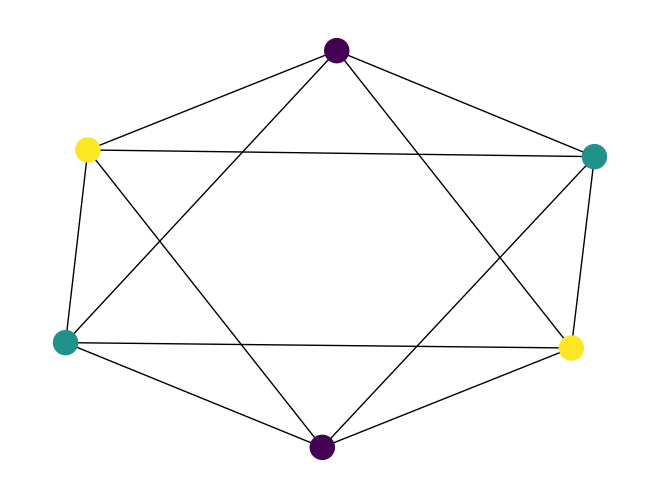

In [9]:
nx.draw(octa, node_color = [octa_coloring[v] for v in octa], pos=nx.spring_layout(octa, seed=4))

The octahedron is 4-regular, so 4-degenerate.  Thus, we are guaranteed a 5-coloring, but we actually get a 3-coloring.

In [10]:
degeneracy_order(icos)

(5, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

In [11]:
icos_coloring = greedy_color_any(icos)

In [12]:
icos_coloring

{11: 0, 10: 1, 9: 0, 8: 1, 7: 2, 6: 0, 5: 1, 4: 2, 3: 3, 2: 2, 1: 3, 0: 4}

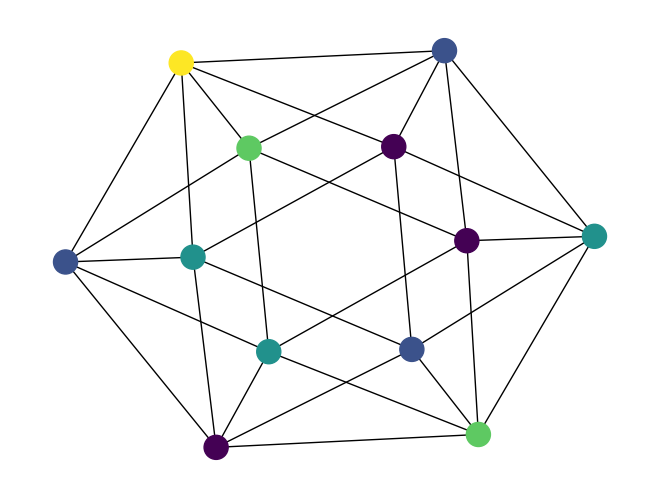

In [13]:
nx.draw(icos, node_color = [icos_coloring[v] for v in icos], pos=nx.spring_layout(icos, seed=7))

The icosahedron is 5-regular, so 5-degenerate.  Thus, we are guaranteed a 6-coloring, but we actually get a 5-coloring.

#### 3.1.2 A Bigger (Running) Example

As a toy example, we generate below a Delaunay triangulation on 200 vertices, `D200`.  The choice of 200 is based mainly on the fact that we want to draw the graph, so adding more vertices would make it harder to see what's happening.  We will continue with this as a running example to illustrate more functions below.  Basically, we pick 200 random points in the unit square, and use them to build a Delaunay triangulation.  To make the picture look a bit nicer, we filter the points to require that no 2 of them are too close together.

**Warning**: If you increase the number of points in the cell below too much, without decreasing the distance threshold $d$, that cell will hang.  This actually makes good sense.  Because the random process will be unable to find that many points in the unit square that are pairwise distance at least $d$ apart.

Create the Delauanay triangulation on 200 points.

In [14]:
num = 200
points = []

d = .03  # min allowable distance from all other earlier points
while len(points) < num:
    p = np.random.rand(2)
    if all(np.linalg.norm(p - q) >= d for q in points):
        points.append(p)

points = np.array(points)

tri = Delaunay(points)  # Delaunay is imported at the top of the notebook

Convert to `nx.Graph` format.

In [15]:
G = nx.Graph()                           # new empty graph
G.add_nodes_from(range(num))             # add in all the vertices, starting from 0

for face in tri.simplices.tolist():      # tolist() converts from dtype np.int32 (which is an np dtpye) to int (which is a python dtype)
    G.add_edges_from([                   # for each face add in its 3 incident edges
        (face[0], face[1]),
        (face[0], face[2]),
        (face[1], face[2])
    ])
D200 = G.copy()   

Extract the coordinates of all the points.

In [16]:
D200pos = {}  # extract the coordinates, to help actually draw the graph
for v in range(len(points)):
    D200pos[v] = points[v] 

And draw the graph with those vertex coordinates.

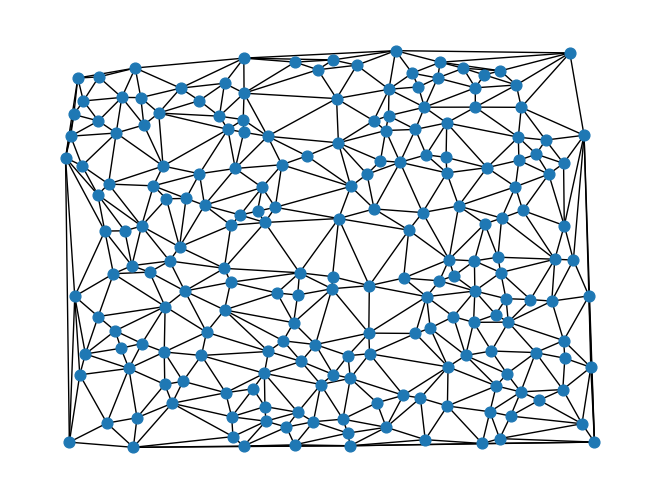

In [17]:
nx.draw(D200, font_size=9, pos=D200pos, node_size=60)

In [18]:
D200_coloring = greedy_color_any(D200)

Or we can greedily color the graph, and draw it with those colors.  Here we use `cmap=plt.cm.tab10, vmin=0, vmax=5`. This is a nice built-in color map.

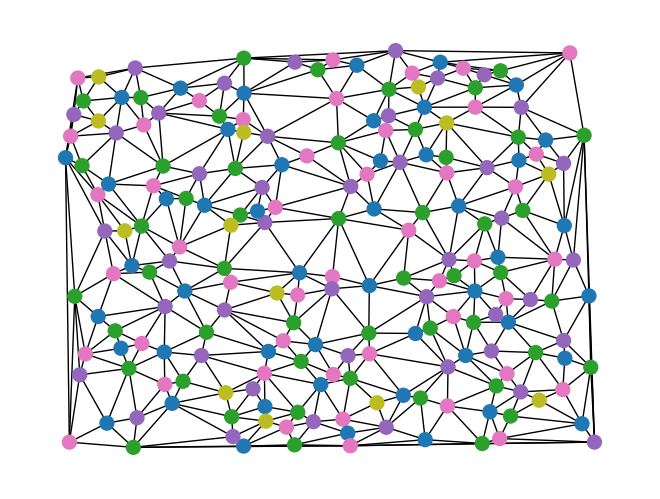

In [19]:
nx.draw(D200, node_color = [D200_coloring[v] for v in D200], font_size=9, pos=D200pos, node_size=100, cmap=plt.cm.tab10, vmin=0,
    vmax=5)

### 3.2 Triangulating Planar Graphs

Our algorithm for acyclically 7-coloring a planar graph $G$ will rely crucially on $G$ being triangulated.  So below we write a helper function to accomplish that.  If a graph is disconnected, then we can add any edge between components, while preserving planarity.  And if a planar graph is 2-connected, then every facial walk is a cycle.  So we can add any chord of a $4^+$-face, internal to the boundary 
cycle $v_1v_2\ldots v_{\ell}$.  We try adding the chord $v_1v_3$; if $v_1v_3$ is already present in $G$, then we add $v_2v_4$.  But when $G$ has connectivity 1, the argument is a bit more delicate, since the boundary walk of a facial cycle may include $v, w, v$, when $w$ is a leaf with $v$ as its neighbor.

In [20]:
def triangulate_planar(G0: nx.Graph) -> nx.Graph:  # take a planar graph and add edges until it is maximal planar
    is_planar, embedding = nx.check_planarity(G0)
    assert is_planar, "Input graph must be planar."
    G = G0.copy()
    n = len(G)
    assert n >= 3, "We can't triangulate a graph with fewer than 3 vertices."
    assert all(v != w for v,w in G.edges), "G must be loopless."  # no loops

    pieces = list(nx.connected_components(G))
    num_comps = len(pieces)

    DEBUG = False
    def dprint(*args):
        if DEBUG:
            print(*args)
    
    if num_comps == 1:
        dprint("Initially connected.")
    else:
        leaders = [piece.pop() for piece in pieces]
        for i in range(1,len(leaders)):
            G.add_edge(leaders[0],leaders[i])

        assert nx.is_connected(G)
        dprint("Initially had", num_comps,"components, but is now connected.")
    
    is_planar, embedding = nx.check_planarity(G)
    assert is_planar
    dprint("Edges", list(G.edges))
    
    seen = set()
    for v,w in embedding.edges:
        if (v,w) not in seen:
            cycle = embedding.traverse_face(v,w, mark_half_edges = seen)
            while len(cycle) > 3:
                dprint("Cycle is",cycle)
                if not G.has_edge(cycle[0], cycle[2]) and (cycle[0] != cycle[2]):
                    G.add_edge(cycle[0], cycle[2])
                    dprint("Added edge",cycle[0],cycle[2])
                    del cycle[1]
                elif not G.has_edge(cycle[1], cycle[3]):
                    dprint("Couldn't add",cycle[0],cycle[2],"so trying to add",cycle[1],cycle[3])
                    dprint("Has edge?",G.has_edge(cycle[1],cycle[3]))
                    dprint("Edges", list(G.edges))
                    assert not G.has_edge(cycle[1],cycle[3])
                    G.add_edge(cycle[1], cycle[3])
                    dprint("Added edge",cycle[1],cycle[3])
                    del cycle[2]
                else:
                    assert len(cycle) >= 5
                    assert not G.has_edge(cycle[2],cycle[4])
                    dprint("Couldn't add edge",cycle[0],cycle[2],"or edge",cycle[1],cycle[3],"so adding edge",cycle[2],cycle[4])
                    G.add_edge(cycle[2],cycle[4])
                    del cycle[3]

    
    dprint("Number of vertices is",n,"and number of edges is",len(G.edges))
    dprint("Edges", list(G.edges))
    assert len(G.edges) == 3*n - 6
    is_planar, embedding = nx.check_planarity(G)
    assert is_planar
    dprint("Edges", list(G.edges))
    pos = nx.combinatorial_embedding_to_pos(embedding)
    assert all(len(embedding.traverse_face(v, w)) == 3
           for v, w in embedding.edges)
    return G, pos  # In addition to the graph, we also return (for easier drawing) vertex positions in a plane embedding.

#### 3.2.1 Example of Triangulating a Planar Graph

In [21]:
def random_tree(n: int):  # creates a "random" tree on n vertices
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(1,n):
        j = random.choice(range(i))
        G.add_edge(i,j)
    return G

In [22]:
tree60 = random_tree(60)

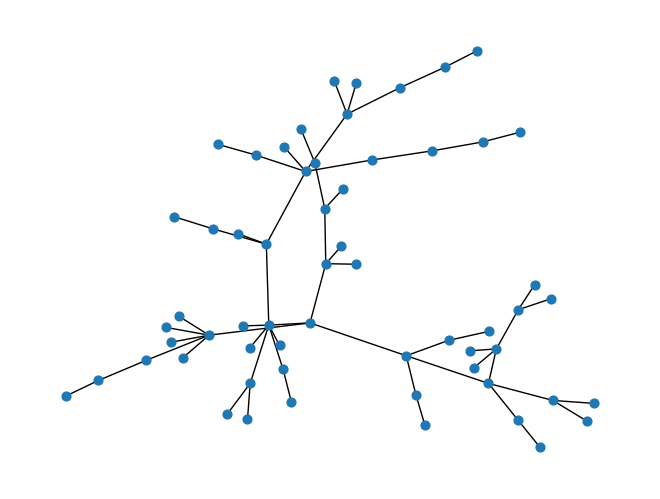

In [23]:
nx.draw(tree60, node_size = 40, pos=nx.spring_layout(tree60, seed=8))

In [24]:
tree60_plus, pos = triangulate_planar(tree60)

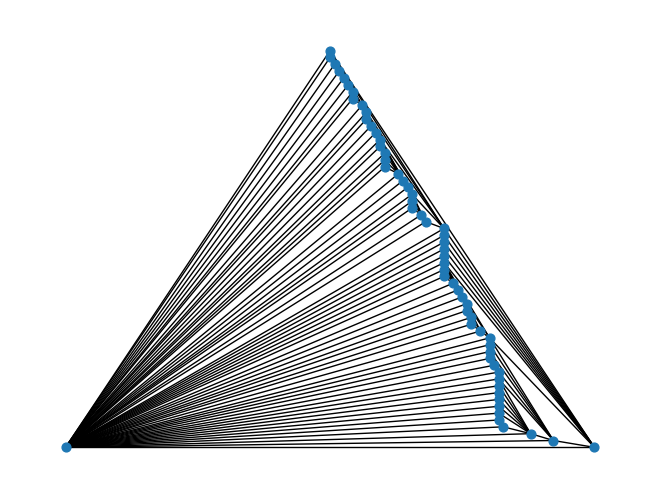

In [25]:
nx.draw(tree60_plus, pos=pos, node_size = 40)

### 3.3 Equitably Coloring Forests

As we mentioned above, all of the proofs eventually equitably partition into forests, and then equitably color those forests.  Unlike for general planar graphs and even outerplanar graphs, in forests finding a maximum independent set is easy: we simply add a leaf to the set, delete its neighbor and recurse.  (Proving the correctness of this algorithm is an easy exercise.)  So below we implement `max_indSet_forest` which does exactly this; it also takes as an optional argument a vertex to include in the independent set.

In [26]:
def max_indSet_forest(H: nx.Graph, v=None):
    assert nx.is_forest(H)
    G = H.copy()
    S = set()
    if v is not None:
        assert v in G
        S = S | {v}
        for w in list(G.neighbors(v)):
            G.remove_node(w)

    leaves = {v for v,d in G.degree if d <=1}

    while leaves:
        v = leaves.pop()  # pick v to have at most one neighbor
        S = S | {v}
        for w in list(G.neighbors(v)):
        #w = next(iter(G.neighbors(v)))
            for x in G.neighbors(w):
                if G.degree(x) <= 2:
                    leaves = (leaves | {x}) 
            leaves.difference_update(set(G.neighbors(v)) | {v})
            G.remove_nodes_from(set(G.neighbors(v)) | {v})

    return len(S), S

Chang's equitable coloring algorithm for forests prefers to work on trees.  So below we write a helper function `treeify_forest` for the conversion.  Roughly speaking, it just repeatedly adds a new edge with endpoints in distinct components.  But we must be a little careful not to decrease $min_{v\in V(G)}\alpha_v$.  Chang proved a lemma that says that we only need to worry about decreasing this minimum by decreasing $\alpha_v$ when $v$ is a *unique* vertex of maximum degree.  And this case is not hard to avoid.

In [27]:
def treeify_forest(F0: nx.Graph) -> nx.Graph:  # given a forest F, return a tree T containing F
    # but also, if F is equitably k-colorable for some k >= 3, then T is also equitably k-colorable
    # to ensure this, never add an edge incident to a unique vert w of max degree, or between 2 non-nbrs of such a w
    F = F0.copy()
    assert nx.is_forest(F)
    max_vert = next(iter(F))
    for v in F.nodes:  # find a vertex of weakly maximum degree
        if F.degree(v) > F.degree(max_vert):
            max_vert = v
            
    if F.degree(max_vert) == 0:  # F has no edges, so just return a path on its vertices
        verts = list(F.nodes())
        for i in range(len(verts)-1):
            F.add_edge(verts[i],verts[i+1])
        return F
        
    while not nx.is_connected(F):
        C = nx.node_connected_component(F,max_vert)
        v1 = next(iter(F.neighbors(max_vert)))  # pick a neighbor of max_vert
        v2 = next(v for v in F if v not in C)  # and a vertex in a component different from v1
        F.add_edge(v1,v2)
        for w in [v1,v2]:
            if F.degree(w) > F.degree(max_vert):
                max_vert = w
    return F

In [28]:
def min_equitable(F: nx.Graph) -> int:
    # takes a forest F (don't care about connectedness); returns minimum integer s such that F is equitably s-colorable
    # correctness below due to Lemma 5 of [Chang, EuJC 2009] only need to check (any) vertex of max degree
    max_vert = max(F, key = F.degree)
    size_for_max_vert, max_set_for_max_vert = max_indSet_forest(F, max_vert)
    s = math.ceil((len(F)+1)/(size_for_max_vert+1))
    return max(s,3)

The function below to equitably color a forest is the most involved that we have seen so far.  So we provide a brief outline here.  We assume the forest F is a tree (or reduce to that case).  So F has a unique bipartition A,B.  We let a = len(A), b = len(B) and assume a >= b.  We compute the target size $\lfloor n/s\rfloor$ of the smallest color class.  The simpler case is when $b \ge \lfloor n/s\rfloor$.
In that case we find one color class to ''straddle'' the boundary between $A$ and $B$, meaning it has vertices in each.  In this case, the existence of the ''straddler'' follows from an averaging argument.  The harder case is when $b < \lfloor n/s\rfloor$.  In that case, we must have 2 color classes that straddle.  We consider 3 different strategies for constructing these straddlers, and at least one of them must succeed.

**need to test equicolor_forest more thoroughly** (and *rename to equi_color_forest*); must ensure that we have test cases covering exits #2 and #3

In [29]:
def equicolor_forest(F0: nx.Graph, s: int) -> dict:
    # get a forest F0 and positive integer s >= 3; want to equitably s-color F0
    F = F0.copy()
    
    DEBUG = False
    def dprint(*args):
        if DEBUG:
            print(*args)
    
    coloring = {}
    assert s >= 3  
    assert s >= min_equitable(F)  # ensure that we're not trying to do the impossible
    n = len(F)
    dprint("n is",n)
            
    connected = nx.is_connected(F)
    # want to assume F is connected; if not, then connected it with treeify
    if not connected:
        F = treeify_forest(F)
        
    assert nx.is_connected(F)
    assert nx.is_forest(F)
    
    A, B = nx.bipartite.sets(F)
    a, b = len(A), len(B)
    dprint("A and B are",A,"and",B)
    dprint("a and b are",a,"and",b)
    if b > a:
        A, B = B, A
        a, b = b, a

    dprint("A and B are",A,"and",B)
    dprint("a and b are",a,"and",b)

    sizes = []
    for i in range(s):
        sizes.append(math.floor((n+i)/s))  # the desired sizes of the color classes
    dprint("sizes is",sizes)

    sum, j = 0, 0
    while sum < b:  # j is the min number of color classes who sum equals or exceeds b
        sum += sizes[j]
        j += 1

    ## Case 0 or 1
    if sum == b or j > 1:  # if sum == b, then first j color classes fix exactly into B
        ## Case 0
        if sum == b:  # we pick verts for color class j-1 now (all others later)
            dprint("Starting Case 0")
            straddlerAB = set()
            straddlerB = set()
            for i in range(sizes[j-1]):  # move sizes[j-1] elements from B to straddlerB
                v = B.pop()
                straddlerAB |= {v}
            # will do this later
            #for v in straddlerB:  # give each v in straddlerB color j-1
            #    coloring[v] = j-1
            dprint("Ending Case 0")

        ## Case 1
        elif j > 0:  # b > math.floor(n/s)
            dprint("Starting Case 1")
            extra = b - sum + sizes[j-1]  # number of vertices in B beyond vertices for colors 0,...,j-2 (first j-1 color classes)

            straddlerA = A.copy()  # will supply vertices for straddlerAB, color class with some vertices in A and others in B
            straddlerB = set()
            Q = []
            for v, d in F.degree:
                dprint("v and d are",v,"and",d)
                if v in B:
                    dprint("B contains",v)
                    heapq.heappush(Q, (d, v))  # load a queue with the vertices of B keyed by their degrees in F
                else:
                    dprint("B does not contain",v)
            dprint("B contains", B)

            dprint("Length of Q is", len(Q))
            assert len(Q) == b
            assert 0 <= extra <= len(Q)
            
            for i in range(extra):  # put into straddlerB the *extra* vertices of B with lowest degrees
                d, v = heapq.heappop(Q)
                straddlerB |= {v}  # add v to target set
                straddlerA.difference_update(F.neighbors(v))

            straddlerAB = straddlerB
            for i in range(sizes[j-1]-extra):
                v = straddlerA.pop()
                straddlerAB |= {v}

            dprint("Ending Case 1")

        dprint("Starting Case 0/1 code")
        # resume common code for Cases 0 and 1
        #
        # build dict with colors 0,...j-2 in B
        B.difference_update(straddlerB)
        curr_color, num_verts_curr_color = 0, 0
        while sizes[curr_color] == 0:
            curr_color += 1
        for v in B:
            coloring[v] = curr_color
            dprint("v and curr_color are",v,"and",curr_color)
            num_verts_curr_color += 1
            dprint("num_verts_curr_color is",num_verts_curr_color)
            if num_verts_curr_color == sizes[curr_color]:
                curr_color += 1  # move to next color
                num_verts_curr_color = 0
        #print("num_verts_curr_color is", num_verts_curr_color)
        #print("curr_color is", curr_color)
        #print("len(B) is",len(B))
        #print("number of verts is",len(F.nodes))
        #print("s is",s)
        assert num_verts_curr_color == 0  # should have exactly packed color classes 0,...,j-2 into (what was left of) B

        # build dict with color j-1 in straddlerAB
        for v in straddlerAB:
            coloring[v] = curr_color

        curr_color += 1
        num_verts_curr_color = 0  # not really necessary

        # build dict with colors j,...s-1 in A
        A.difference_update(straddlerAB)
        for v in A:
            coloring[v] = curr_color
            # print("v and curr_color are",v,"and",curr_color)
            num_verts_curr_color += 1
            # print("num_verts_curr_color is",num_verts_curr_color)
            if num_verts_curr_color == sizes[curr_color]:
                curr_color += 1
                num_verts_curr_color = 0

        dprint("Ending Case 0/1 code")

    else:  # j == 0 and b < sum ; thus, b < math.floor(n/s) 
        ## Case 2  
        dprint("Starting Case 2")
        # define L
        L = {v for v in A if F.degree(v) <= 1}  # leaves in A
        # initialize S
        S = B.copy()
        # "locally" minimize S
        changed = True
        while (changed == True):
            changed = False
            # check if |N(S-v) n L u (B-(S-v))| >= ceil(n/s)
            for v in S:
                S_temp = S - {v}
                B_temp = B - S_temp
                N_temp = {w for x in S_temp for w in F.neighbors(x)}
                if len((N_temp & L) | (B_temp - S_temp)) >= math.ceil(n/s):
                    S = S_temp
                    changed = True
                    break
                    
        # if |N(B-S) n L| + |S| >= math.floor(n/s):
        # BmS is B-S and nbrs_Bms is N(B-S)
        
        nbrs_S = {w for x in S for w in F.neighbors(x)}
        BmS = B - S
        nbrs_BmS = {w for x in BmS for w in F.neighbors(x)}
        if len(nbrs_BmS & L) + len(S) >= math.floor(n/s):  # exit 1 in the proof
            # extend S to C_0
            C_0 = S  # color class 0 (first/smallest)
            A0 = L - nbrs_S
            for i in range(math.floor(n/s) - len(C_0)):
                v = A0.pop()
                A.difference_update({v})
                C_0 |= {v}
            for v in C_0:
                coloring[v] = 0

            # extend nbr_S to C_sm1
            C_sm1 = B - S  # color class s-1 (final/biggest)
            A1 = L & nbrs_S
            for i in range(math.ceil(n/s) - len(C_sm1)):
                v = A1.pop()
                A -= {v}
                C_sm1 |= {v}
            for v in C_sm1:
                coloring[v] = s-1

            dprint("Done with most of `exit 1' (Case 2a), but still need to build the dictionary for color classes 1 through",s-2)
            # return coloring
            # end of exit 1

        else:
            # initialize R
            v = next(iter(S))
            v_size, R = max_ind_set(F, v)
            assert v_size >= math.floor(n/s)
     
            # "locally" minimize R, first removing vertices in B
            for w in R & (B - {v}):
                if len(R) > math.floor(n/s):
                    R -= {w}
            for w in R - B:
                if len(R) > math.floor(n/s):
                    R -= {w}
            # now R has size exactly math.floor(n/s)
            changed = True
            while changed == True and len(R & (B-{v})) >= 1:
                changed = False
                for w in A - R:
                    if len(set(F.neighbors(w)) & R) == 0:
                        R |= {w}
                        R -= next(iter(R & (B-{v})))
                        changed = True
                        break
                    

            if len(R & (B-{v})) == 0:  # exit 2 in the proof (v is only vertex of B in R)
                dprint("Exit 2 in proof")
                for w in R:
                    coloring[w] = 0
                    dprint("Vertex",w,"has color 0")
                    A -= {w}
                    # B -= {w}
            
                for w in B - {v}:
                    coloring[w] = s-1
                    # B -= {w}
                    dprint("Vertex",w,"has color",s-1)
                A0 = L & set(F.neighbors(v))  # candidates to add to B - {v}
                dprint("Sizes[s-1] is", sizes[s-1],"and len(B-{v}) is", len(B-{v}))
                for i in range(sizes[s-1]-len(B-{v})):
                    dprint("i is",i)
                    w = A0.pop()
                    A -= {w}
                    coloring[w] = s-1
                    dprint("Vertex",w,"has color",s-1)
            

            else:  # exit 3 in the proof
                dprint("Exit 3 in proof")
                for w in R:
                    coloring[w] = 0
                    dprint("Vertex",w,"has color 0")
                    A -= {w}
                    # B -= {w}
            
                R_nbrs_in_L = {w for x in R & B for w in F.neighbors(x)}
                for w in B - R:
                    coloring[w] = s-1
                    print("Vertex",w,"has color",s-1)
                    # B -= {w}
                
                A0 = R_nbrs_in_L  # candidates to add to B - R
                dprint("A0 is", A0)
                for i in range(sizes[s-1]-len(B-R)):
                    w = A0.pop()
                    A -= {w}
                    coloring[w] = s-1
                    dprint("Vertex",w,"has color",s-1)

        dprint("Finally creating color classes 1 through",s-2)
        # finally, make color classes 1,...,s-2 out of remaining vertices in A
        curr_color, num_verts_curr_color = 1, 0
        while sizes[curr_color] == 0:
            curr_color += 1
        dprint("A is",A)
        for v in A:
            coloring[v] = curr_color
            # print("v and curr_color are",v,"and",curr_color)
            num_verts_curr_color += 1
            # print("num_verts_curr_color is",num_verts_curr_color)
            if num_verts_curr_color == sizes[curr_color]:
                curr_color += 1  # move to next color
                num_verts_curr_color = 0
        
        #assert curr_color == s-1
        #assert num_verts_curr_color == 0

    assert all(coloring[v] != coloring[w] for v,w in F.edges())  # coloring is proper
    totals = [0 for i in range(s)]  # and equitable (this and next 3 lines)
    for v in coloring:
        totals[coloring[v]] += 1
    assert totals == sizes
        
    return coloring

#### 3.3.1 Examples

In [30]:
path11 = nx.path_graph(11)
star12 = nx.star_graph(12)
print("Path11 has vertices", path11.nodes, "\nand edges", path11.edges)
print("Star12 has vertices", star12.nodes, "\nand edges", star12.edges)

Path11 has vertices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 
and edges [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10)]
Star12 has vertices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] 
and edges [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12)]


In [32]:
print(max_indSet_forest(path11))
print(max_indSet_forest(path11, 4))
print(max_indSet_forest(path11, 7))
print(max_indSet_forest(star12))
print(max_indSet_forest(star12, 3))
print(max_indSet_forest(star12, 0))

(6, {0, 2, 4, 6, 8, 10})
(6, {0, 2, 4, 6, 8, 10})
(5, {0, 2, 4, 7, 9})
(12, {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12})
(12, {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12})
(1, {0})


In [33]:
def random_forest(n: int, p = .8):  # creates a "random" forest on n vertices
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(1,n):
        j = random.choice(range(i))
        flip = np.random.rand(1)[0] < p
        if flip:
            G.add_edge(i,j)
    return G

In [34]:
rand_F40 = random_forest(40,.7)

In [35]:
# test treeify
num_comps_F = len(list(nx.connected_components(rand_F40)))
rand_T40 = treeify_forest(rand_F40)
num_comps_T = len(list(nx.connected_components(rand_T40)))
print("rand_F40 has", num_comps_F, "components and rand_T40 has", num_comps_T)
assert all((v,w) in rand_T40.edges for v,w in rand_F40.edges)

rand_F40 has 13 components and rand_T40 has 1


### 3.4 Acyclically 7-Coloring Planar Graphs

Recall that a proper coloring is acyclic if the subgraph induced by the union of every 2 color classes is acyclic. In this section, given any planar graph $G$ we construct an acyclic 7-coloring of $G$.  This is a 1977 theorem of Albertson and Berman.  

**Theorem [AB]**: If $G$ is a planar graph, then $G$ has an acyclic 7-coloring.

Our implementation mostly follows the presentation of Cranston and West [CW] (Lemma 7.1 and Theorem 7.2) https://arxiv.org/abs/1306.4434v1 But that presentation is not focused on yielding an efficient algorithm. It readily yields a polynomial algorithm. But to get something that runs in linear time requires a few more finesses.  

The proof in [CW] proceeds by minimal counterexample, which naturally translates into a proof by induction.  The main idea is to find a *reducible configuration*, locally modify the graph $G$ to get a smaller graph $G'$, recursively get an acyclic 7-coloring $\varphi'$ of $G'$, and then modify $\varphi'$ to get an acyclic 7-coloring $\varphi$ of $G$.  Each reducible configuration has constant size, so this process will take a linear number of recursive calls.  More precisely, each time that we recurse it is on a graph with order 1 smaller 
or 2 smaller.  So the final recursion depth will be at least half the order of the graph.  The theorem of Albertson and Berman proves
that every plane triangulation contains one of 4 types of reducible configuration, each centered around a vertex of low degree.  Each type has bounded size, so we can find one in linear time, by just looking at each vertex in the graph and exploring the neighborhood of each vertex of degree at most 7.  Naively, this takes linear time, since we must look at linearly many degrees (in the worst case) just to find a reducible configuration.

Instead of this naive approach, we maintain a collection (either a list or set is fine) of all the low degree vertices in the graph.  More precisely, we put vertices into `candidates` when their degree drops to 7.  We don't work to keep `candidates` up to date.  So later when we pop from candiates, we might get a vertex whose degree has since increased, or even one that has been removed from the graph.  We simply discard these ''stale'' candidates and continue popping until we find one that is really the center of a reducible configuration.  After we reduce to a smaller graph, we also need to add potential new low degree vertices to `candidates`.  When we initially populate `candidates` we spend time $O(n)$.  But the key point is that each time we recurse we only add a constant number of vertices to `candidates`.  This allows us to find a reducible configuration in *amortized constant time*.  (**Currently, this is not quite right.**  We may try a bunch of candidates that are each not presently the center of a reducible configuration, but that are also not stale, so cannot be discarded.  I suspect this can be fixed to be made precisely amortized constant time.  But currently I do not see the details.)

**Reducible Configurations** Since $G$ is a plane triangulation, we have $\delta(G) \ge 3$.  The 4 classes of reducible configurations are (i) a 3-vertex, (ii) a 4-vertex with a $6^-$-neighbor, (iii) a 7-vertex with two 4-neighbors, and (iv) a 5-vertex $v$ with a $6^-$-neighbor $u$ such that the two common neighbors $x,y$ of $u,v$ are neither adjacent nor on a separating 4-cycle.

**Warning**: The function below is *recursive*.  Each recursive call decreases the order of the graph by 1 or 2.  So with sufficiently large graphs you will likely exceed the (default) recursion depth.  This is not a significant problem.  You just need to increase this value.  Below we give an example of how to do this.

In [36]:
def acyclic_color_planar(G0: nx.Graph) -> dict:
    # A proper coloring is *acyclic* if the subgraph induced by any 2 color classes has no cycles.
    # Here we implement a result of Albertson and Berman, showing that 7 colors suffice for all planar graphs.
    is_planar, embedding = nx.check_planarity(G0)
    assert is_planar, "Input graph is not planar!"
    G, pos = triangulate_planar(G0)  # also returns the coordinates of each vertex in the plane embedding
    is_planar, embedding = nx.check_planarity(G)  # need embedding to be of G, rather than G0
    assert is_planar, "Something is wrong with triangulate_planar."
    color = {}
    
    def find_color(color_set):
        free_color = 0  # colors start from 0; if we want from 1, change here and in base case
        while free_color in color_set:
            free_color += 1
        return free_color

    # The algorithm acolor_recursive() needs access to an embedding of G.  Recomputing after each reduction will be expensive.
    # So we need to update the embedding each time we process a reducible configuration, before we recurse.
    # This is not conceptually difficult, but tedious.  So we write some helper functions, the next 4 below.

    def destroy_node(v):
        G.remove_node(v)
        embedding.remove_node(v)
        
    def restore_node(v: node, v_nbrs: list):
        G.add_node(v)
        embedding.add_node(v)
        d = len(v_nbrs)
        for i in range(d):  # restore half-edges *to* v
            embedding.add_half_edge_cw(v_nbrs[i],v,v_nbrs[(i+1)%d])
            G.add_edge(v,v_nbrs[i])
            
        embedding.add_half_edge(v,v_nbrs[0]) # restore half-edges *from* v
        for i in range(len(v_nbrs)-1): 
            embedding.add_half_edge_cw(v,v_nbrs[i+1],v_nbrs[i])

    def add_chord(v_nbrs):
        if  G.has_edge(v_nbrs[1],v_nbrs[3]):  # rotate v_nbrs by 1, so that (new) edge w1w3 is absent
            v_nbrs = v_nbrs[3:] + v_nbrs[:3]  # by rotating, we avoid splitting into 2 cases
                
        G.add_edge(v_nbrs[1],v_nbrs[3])
        embedding.add_half_edge_cw(v_nbrs[1], v_nbrs[3], v_nbrs[2])
        embedding.add_half_edge_cw(v_nbrs[3], v_nbrs[1], v_nbrs[0])
        return(v_nbrs)

    def remove_chord(v_nbrs):
        #print("G has edge",v_nbrs[1],v_nbrs[3],G.has_edge(v_nbrs[1],v_nbrs[3]))
        #print("Removing chord",v_nbrs[1],v_nbrs[3])
        G.remove_edge(v_nbrs[1],v_nbrs[3])
        #print("G has edge",v_nbrs[1],v_nbrs[3],G.has_edge(v_nbrs[1],v_nbrs[3]))
        #print("Embedding has edge",embedding.has_edge(v_nbrs[1],v_nbrs[3]), embedding.has_edge(v_nbrs[3],v_nbrs[1]))
        embedding.remove_edge(v_nbrs[1], v_nbrs[3])
        # don't need to remove the half-edges separately, get them both from removing a single edge
        #embedding.remove_edge(v_nbrs[3], v_nbrs[1])
        #print("Embedding has edge",embedding.has_edge(v_nbrs[1],v_nbrs[3]), embedding.has_edge(v_nbrs[3],v_nbrs[1]))

    # If we search anew for a reducible configuration each time we recurse, this will take time O(n), but since we have O(n)
    # recursive calls, this will yield a running time of O(n^2), which is too slow.  Instead we maintain a set candidates that always
    # contains a low degree vertex in each reducible configuration in G.  It is possible that candidates will have stale candidates,
    # that have either been removed from G or might no longer be a valid reducible configuration.  But after each update (before recursing)
    # we add only a constant number of candidates.  So candidates always has size at most O(n).  And crucially, it is always nonempty!
    # Thus, we can find a valid candidate in *amortized* constant time.
    
    def candidate(v):  
        maybe = G.degree(v) <= 7
        # we run a looser filter on candidates than needed, so that updating later is simpler
        # in particular candidate(v) only changes when G.degree(v) changes
        
        return maybe

    candidates = {v for v in G if candidate(v)}  # populate candidates by brute force before we first call acolor_recursive()

    def acolor_recursive():  # by induction on len(G); expects a plane triangulation
        nonlocal candidates
        
        if len(G) <= 7:  # base case; colors start from 0
            for i, v in enumerate(G):
                color[v] = i
            return

        
        # find a reducible configuration
        case_num = 0  # not a reducible configuration

        candidates_to_reinsert = set()
        while case_num == 0:
            
            while True:  # ensure that v is currently in G, since we make no effort to keep candidates a subset of G.nodes
                if not candidates:
                    assert False, "No candidates remain. =("
                v = candidates.pop()
                if G.has_node(v):
                    v_nbrs = list(embedding.neighbors_cw_order(v))  # we will need these in each case below
                    break

            if G.degree(v) == 3:  # reducible configuration #1
                case_num = 1

            elif G.degree(v) == 4 and any(G.degree(w) <= 6 for w in G.neighbors(v)):  # reducible configuration #2
                w = min(v_nbrs, key = G.degree)
                if G.degree(w) == 3:  # actually, nearby copy of reducible configuration #1
                    v = w
                    v_nbrs = list(embedding.neighbors_cw_order(v))
                    case_num = 1
                else:
                    case_num = 2

            elif (G.degree(v) == 7 and sum(G.degree(w) <= 4 for w in v_nbrs) >= 2):  # reducible configuration #3
                min_nbr = min(v_nbrs, key = G.degree)
                if G.degree(min_nbr) == 3:  # actually, nearby copy of reducible configuration #1
                    v = min_nbr
                    v_nbrs = list(embedding.neighbors_cw_order(v))
                    case_num = 1
                else:
                    v_nbrs_4s = [w for w in v_nbrs if G.degree(w) == 4]
                    #assert len(v_nbrs_4s) >= 2
                    x, y = v_nbrs_4s[:2]
                    if G.has_edge(x,y):
                        v,u = x,y
                        v_nbrs = list(embedding.neighbors_cw_order(v))
                        case_num = 2  # actually, nearby copy of reducible configuration #2
                    else:
                        case_num = 3

            elif (G.degree(v) == 5 and any(G.degree(w) <= 6 for w in v_nbrs)):  # reducible configuration #4 
                                                                                # (if v not on separating 3-cycle or 4-cycle)
                u = min(v_nbrs, key = G.degree)
                if G.degree(u) == 3:  # actually, nearby copy of reducible configuration #1
                    case_num = 1
                    v = u
                    v_nbrs = list(embedding.neighbors_cw_order(v))
                elif G.degree(u) == 4:  # actually, nearby copy of reducible configuration #2
                    v,u = u,v
                    v_nbrs = list(embedding.neighbors_cw_order(v))
                    case_num = 2
                else:  # need to ensure that v does not lie on separating 3-cycle or 4-cycle with successor and predecessor of u
                    u_nbrs = list(embedding.neighbors_cw_order(u))  # will want this later, when case_num == 4
                    i = v_nbrs.index(u)
                    v_nbrs = v_nbrs[i:] + v_nbrs[:i]  # rotate v_nbrs so that u is first (index 0)
                    x, y = v_nbrs[-1], v_nbrs[1]
                    # don't actually know that len(x_nbrs) and len(y_nbrs) are bounded; might not run in constant time!
                    # could probably modify discharging argument to ensure that x and y both have bounded degree; would resolve the issue
                    x_nbrs = list(embedding.neighbors_cw_order(x))
                    i = x_nbrs.index(v)
                    x_nbrs = x_nbrs[i:] + x_nbrs[:i]  # rotate x_nbrs so that v is first
                    y_nbrs = list(embedding.neighbors_cw_order(y))
                    j = y_nbrs.index(v)
                    y_nbrs = y_nbrs[j:] + y_nbrs[:j]  # rotate x_nbrs so that v is first
                    
                    if G.has_edge(x,y) or len(set(x_nbrs) & set(y_nbrs) - {v,u}) >= 1:
                         continue
                    case_num = 4
                  
                        
            if case_num == 0:
                candidates_to_reinsert.add(v)
            else:
                candidates |= candidates_to_reinsert
            
        
        if case_num == 1:  # G has a 3-vertex v:
            case1(v, v_nbrs)
            
        elif case_num == 2:  # G has a 4-vertex with a 6^--nbr
            case2(v, v_nbrs)

        elif case_num == 3: # G has a 7-vertex v with two 4-nbrs x, y
            case3(v, v_nbrs, x, y)
            
        elif case_num == 4:  # G has a 5-vertex v with a 6^--nbr u and v not on a separating 3-cycle or 4-cycle
                # forbidding a separating 3-cycle needs a slightly stronger version of Lemma 7.1 (from the Guide) by the same proof
            case4(v, v_nbrs, u, u_nbrs, x, x_nbrs, y, y_nbrs)                
            
        else:
            assert False, "We should not be here! One of the earlier cases should have triggered (or we should have found a new candidate)."


    def case1(v, v_nbrs):
        nonlocal candidates
        destroy_node(v)
        candidates |= {w for w in v_nbrs if candidate(w)}

        acolor_recursive()  # recursively color G-v
        
        restore_node(v, v_nbrs)

        # find a color for v
        used_colors = {color[w] for w in v_nbrs}
        color[v] = find_color(used_colors)  # give v the free color
        

    def case2(v, v_nbrs):
        nonlocal candidates
        min_nbr = min(v_nbrs, key = G.degree)
        assert G.degree(min_nbr) <= 6
        i = v_nbrs.index(min_nbr)
        v_nbrs = v_nbrs[i:] + v_nbrs[:i]  # rotate v_nbrs so that v_nbrs[min_nbr] is first

        destroy_node(v)
        v_nbrs = add_chord(v_nbrs)
        candidates |= {w for w in v_nbrs if candidate(w)}

        acolor_recursive()  # recursively color G-v + w1w3
        
        remove_chord(v_nbrs)
        restore_node(v, v_nbrs)  # still need to color v

        # find colors for v to avoid 
        used_colors = {color[w] for w in v_nbrs}
        if len(used_colors) == 3:  # two neighbors of v got the same colors
            # so we also will avoid the colors on the nbrs of the one of these with lower degree (<=6)
            more_used_colors = {color[x] for x in G.neighbors(v_nbrs[0]) if x != v}
            used_colors |= more_used_colors
            assert len(used_colors) <= 6
        else:
            assert len(used_colors) == 4

        color[v] = find_color(used_colors) 

    def case3(v, v_nbrs, x, y):
        nonlocal candidates
        x_nbrs = list(embedding.neighbors_cw_order(x))
        x_i = x_nbrs.index(v)
        x_nbrs = x_nbrs[x_i:] + x_nbrs[:x_i]  # rotate x_nbrs, so v is first
        destroy_node(x)
        x_nbrs = add_chord(x_nbrs)
        #
        y_nbrs = list(embedding.neighbors_cw_order(y))
        y_i = y_nbrs.index(v)
        y_nbrs = y_nbrs[y_i:] + y_nbrs[:y_i]  # rotate y_nbrs, so v is first
        destroy_node(y)
        y_nbrs = add_chord(y_nbrs)

        candidates |= {w for w in x_nbrs + y_nbrs + [v] if candidate(w)}
        
        acolor_recursive()
        
        remove_chord(x_nbrs)
        remove_chord(y_nbrs)
        restore_node(x, x_nbrs)
        restore_node(y, y_nbrs)

        x_colors_used = {color[w] for w in x_nbrs}  # has len <= 4
        y_colors_used = {color[w] for w in y_nbrs}  # has len <= 4
        v_colors_used = {color[w] for w in v_nbrs if w not in {x,y} } | {color[v]}  # has len <= 6
            
        if len(x_colors_used) == 4 and len(y_colors_used) == 4:  # all nbrs of x got distinct colors; same for y
            color[x] = find_color(x_colors_used)
            color[y] = find_color(y_colors_used)

        elif len(x_colors_used) == 3 and len(y_colors_used) == 4:
            color[x] = find_color(v_colors_used)  # v_colors_used contains the set x_colors_used
            color[y] = find_color(y_colors_used)

        elif len(x_colors_used) == 4 and len(y_colors_used) == 3:
            color[x] = find_color(x_colors_used)
            color[y] = find_color(v_colors_used)  # v_colors_used contains the set y_colors_used

        elif len(x_colors_used) == 3 and len(y_colors_used) == 3:
            if len(v_colors_used) <= 5:
                color[x] = find_color(v_colors_used)
                color[y] = find_color(v_colors_used | {color[x]})
            else: 
                assert len(v_colors_used) == 6
                color[v] = find_color(v_colors_used)
                color[x] = find_color(x_colors_used | {color[v]})
                color[y] = find_color(y_colors_used | {color[v]})


    def case4(v, v_nbrs, u, u_nbrs, x, x_nbrs, y, y_nbrs):
        nonlocal candidates
        # before being passed, v_nbrs is rotated to start with u; and x_nbrs, y_nbrs are rotated to start with v
        # also checked above that set(x_nbrs) & set(y_nbrs) - {u,v} is emptyset

        a,b = v_nbrs[2:4]
        a_nbrs = list(embedding.neighbors_cw_order(a))
        b_nbrs = list(embedding.neighbors_cw_order(b))
        a_nbrs_old = a_nbrs.copy()
        b_nbrs_old = b_nbrs.copy()
        u_nbrs_old = u_nbrs.copy()
        v_nbrs_old = v_nbrs.copy()
        u_pred_y = u_nbrs[(u_nbrs.index(y)-1)% len(u_nbrs)]
        a_succ_y = a_nbrs[(a_nbrs.index(y)+1)% len(a_nbrs)]
        u_succ_x = u_nbrs[(u_nbrs.index(x)+1)% len(u_nbrs)]
        b_pred_x = b_nbrs[(b_nbrs.index(x)-1)% len(b_nbrs)]

        # contract(v, x, y)  ### contract vertices x and y onto vertex v
        destroy_node(v)
        destroy_node(x)
        destroy_node(y)
        # z is the new node that results from contracting x and y onto v
        # will start z_nbrs with u
        z_nbrs = y_nbrs[1:] + x_nbrs[1:-1]  # omit v from y_nbrs and omit both v,u from x_nbrs
        # z = max(G)+1
        z = object()  # need to create something to be z; this route avoids assuming that vertices are positive integers
        restore_node(z, z_nbrs)

        candidates |= {w for w in {z, u} if candidate(w)}     
        acolor_recursive()
        
        # uncontract(v, x, y)  ### put everything back to how it was (except for the added colors) before contract(v, x, y)
        z_color = color[z]  # remember the color of z, so that we can give it to x,y soon
        destroy_node(z)
        del color[z]
            
        # just add in these 4 half-edges for a bit, to restore v
        embedding.add_half_edge_cw(u,a,u_pred_y)
        embedding.add_half_edge_ccw(a,u,a_succ_y)
        embedding.add_half_edge_cw(b,u,b_pred_x)
        embedding.add_half_edge_ccw(u,b,u_succ_x)
        restore_node(v, [v_nbrs[0]] + v_nbrs[2:4])  # putting back v, but without edges to x,y (since they don't exist yet)
        embedding.remove_edge(u,a)
        embedding.remove_edge(u,b)
        
        restore_node(y, y_nbrs)
        restore_node(x, x_nbrs)
        color[x] = color[y] = z_color

        # find color for v
        v_used_colors = {color[w] for w in v_nbrs}
        u_used_colors = {color[w] for w in u_nbrs if w != v}

        if len(v_used_colors) == 4:  # all nbrs of v used distinct colors
            color[v] = find_color(v_used_colors)
        else:  # len(v_used_colors) == 3; so u used same color as some other nbr of v
            colors_to_avoid = v_used_colors | u_used_colors
            assert len(colors_to_avoid) <= 6
            color[v] = find_color(colors_to_avoid)
    
    def verify_acolor():
        assert len(color) == len(G)
        assert all(G.has_edge(v,w) for v,w in G0.edges)  # make sure that we really have restored to G all edges of G0 
        colors_used = set(color.values())  
        assert len(colors_used) <= 7, "We used more than 7 colors! But we should not have done that."
        color_classes = {c:set() for c in colors_used}
        for v in G:  # extract the color classes from the coloring
            color_classes[color[v]] |= {v}
    
        # check that each pair of color classes does indeed induce an acyclic subgraph
        assert all(nx.is_forest(G.subgraph(color_classes[i] | color_classes[j])) 
                   for (i,j) in combinations(colors_used,2))

    acolor_recursive()
    verify_acolor()
    return color, pos  # color is the acyclic 7-coloring, and pos is the vertex coordinates, for easier drawing
    
    

#### 3.4.1 Acyclically 7-Coloring our Running Example

In [37]:
D200_acoloring = acyclic_color_planar(D200)[0]  # just keep the colors; drop the coordinates of the points

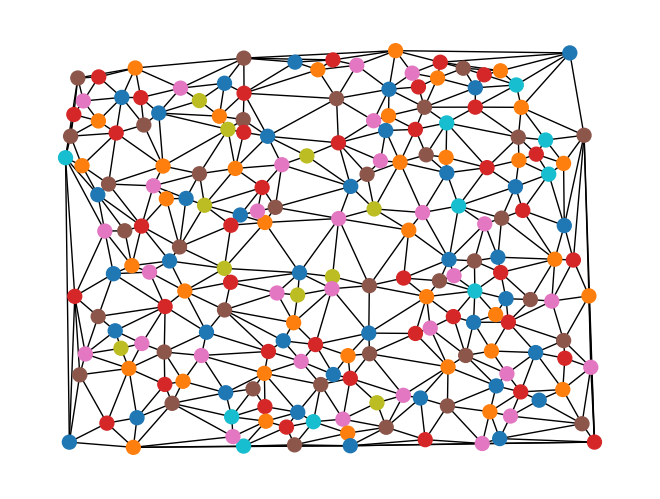

In [38]:
nx.draw(D200, node_color = [D200_acoloring[v] for v in D200], font_size=9, pos=D200pos, node_size=100, cmap=plt.cm.tab10, vmin=0,
    vmax=6)

Now, let's try a (much) bigger graph, which we won't draw.  As mentioned above, we need to increase our recursion limit.
Roughly, Python adds 2 frames to the recursion stack for every recursive call of the acyclic coloring algorithm.  We will try a 20,000-vertex graph.  Each recursive call decreases the order by 1 or 2, so we will have at most 20,000 recursive calls to the function.
Thus, a recursion limit of 50,000 will be more than enough.

In [39]:
sys.setrecursionlimit(50000)

In [40]:
num = 20000
points = np.random.rand(num, 2)

tri = Delaunay(points)  # Delaunay is imported at the top of the notebook

In [41]:
G = nx.Graph()                           # new empty graph
G.add_nodes_from(range(num))             # add in all the vertices, starting from 0

for face in tri.simplices.tolist():      # tolist() converts from dtype np.int32 (which is an np dtpye) to int (which is a python dtype)
    G.add_edges_from([                   # for each face add in its 3 incident edges
        (face[0], face[1]),
        (face[0], face[2]),
        (face[1], face[2])
    ])
D20000 = G.copy()   

The next cell may run for serveral seconds, since we're finding an acyclic coloring for a 20,000-vertex graph.

In [42]:
D20000_acoloring = acyclic_color_planar(D20000)[0]  # just keep the colors; drop the coordinates of the points

In [43]:
set(D20000_acoloring.values())

{0, 1, 2, 3, 4, 5, 6}

In [44]:
assert all(D20000_acoloring[v] != D20000_acoloring[w] for v,w in D20000.edges)

In [47]:
forest = [set() for i in range(7)]
for v,forest_num in D20000_acoloring.items():
    forest[forest_num].add(v)
assert all(nx.is_forest(nx.subgraph(D20000, forest[i] | forest[j])) for i,j in combinations(range(7),2))

### 3.5 Equipartitioning Planar Graphs into Forests

The final lemma we need is due to Esperet, Lemoine, Maffray https://arxiv.org/abs/1410.0861 
Their proof use a simple, but clever, induction on the number of color classes (equivalently, the number of forests).

**Lemma [ELM]**: Fix an integer $k \geqslant 2$. If a graph $G$ has an acyclic coloring with at most $k$ colors, then $G$ can be equitably partitioned into $k-1$ induced forests.


Borodin's result (that every planar graph has an acyclic 5-coloring) shows that every planar graph can be equitably partitioned into *4 forests*.  By instead using the above result of Albertson and Berman, we get the weaker bound that *6 forests* suffice for all planar graphs.  This yields a slightly worse bound for acyclicly coloring planar graphs, but not too much worse.

In [48]:
def equi_forest_planar(G0: nx.Graph, k: int)->dict:
    assert k >= 6, "We need at least 6 forests."
    G = G0.copy()
    n = len(G)
    coloring = acyclic_color_planar(G)[0]  # returns an acyclic 7-coloring

    totals = [0]*(k+1)
    remaining = set(range(k+1))
    foresting = {}

    for v in G:
        totals[coloring[v]] += 1

    for i in range(k):  # find forest i
        # we will take *all* of the smallest color class
        min_tot_in = min(remaining, key = lambda i: totals[i])  # totals.__getitem__)
        # and *some* of the biggest color class
        max_tot_in = max(remaining - {min_tot_in}, key = lambda i: totals[i])  # ensure that max_tot_in != min_tot_in
        # print("For forest", i, "min_tot_in is", min_tot_in, "and max_tot_in is",
        #      max_tot_in, "and these have sizes", totals[min_tot_in], "and", totals[max_tot_in])

        target_size = math.floor((n+i)/k)
        # print("Target size is:", target_size)
        # each forest will have size floor(n/k) or ceil(n/k), with sizes weakly increasing
        curr_size = 0

        # first we put all of the (current) smallest color class into forest i
        for v in list(coloring): 
            if coloring[v] == min_tot_in:
                foresting[v] = i
                del coloring[v]
                curr_size += 1

        # then we keep putting vertices into forest i until it reaches the desired size
        for v in list(coloring): 
            if coloring[v] == max_tot_in:
                if curr_size < target_size:
                    foresting[v] = i
                    del coloring[v]
                    totals[max_tot_in] -= 1
                    curr_size += 1
                else:
                    break

        remaining.remove(min_tot_in)  # update remaining to note that color class min_tot_in is now used up

    for i in range(k):
        forest_i = {v for v, num in foresting.items() if num == i}
        #print("Forest",i,"has size",len(forest_i),"but floor(n/k) is",math.floor(n/k))
        #print("forest_i has length",len(forest_i),"and math.floor((n+i)/k) is", math.floor((n+i)/k))
        assert len(forest_i) == math.floor((n+i)/k)
        assert nx.is_forest(nx.subgraph(G, forest_i))

    return foresting

In [49]:
foresting200 = equi_forest_planar(D200,6)

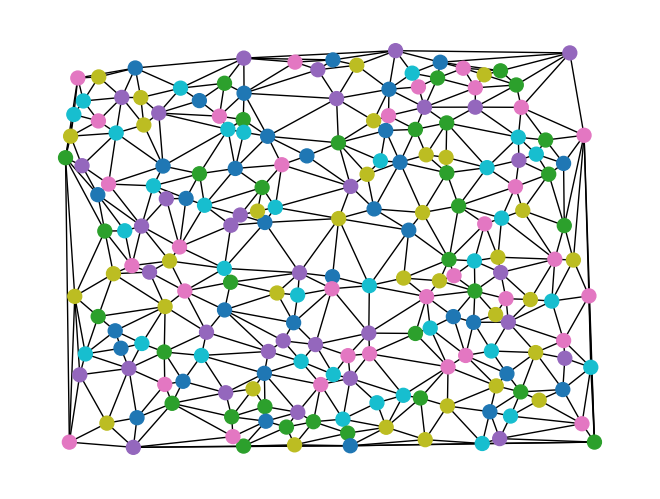

In [50]:
nx.draw(D200, node_color = [foresting200[v] for v in D200], font_size=9, pos=D200pos, node_size=100, cmap=plt.cm.tab10, vmin=0,
    vmax=5)

This "coloring" of D200 is no longer a proper coloring, but rather an equitable forest partition.  So you will see monochromatic components of order 2 or more, but they should all be acyclic.  Also, each color appears either $\lfloor 200/6\rfloor = 33$ or $\lceil 200/6\rceil = 34$ times.

In [52]:
nodes_per_color = [0] * 6
for v in foresting200:
    nodes_per_color[foresting200[v]] += 1
print(nodes_per_color)

[33, 33, 33, 33, 34, 34]


## 4. Equitably Coloring Planar Graphs

### 4.1 Statement of the Planar Theorem and Discussion

In the paper, Cranston and Mahmoud prove the following result.

**Planar Theorem**: Fix $s\geqslant 40$, and let $G$ be a planar graph. Let $w_0,w_1$ be its 2 vertices with
largest degrees, breaking ties arbitrarily. If there exist disjoint independent sets $I_0,I_1$ such that
$|I_0|= \lfloor n/s\rfloor$ and $|I_1|= \lfloor(n+ 1)/s\rfloor$ and $w_0,w_1 \in I_0\cup I_1$, then $G$ has an equitable $s$-coloring.

Here, because we use acyclic 7-coloring, rather than acyclic 5-coloring, we implement the following slightly weaker result.

**Planar Theorem (adapted)**: Fix $s\geqslant 61$, and let $G$ be a planar graph. Let $w_0,w_1$ be its 2 vertices with
largest degrees, breaking ties arbitrarily. If there exist disjoint independent sets $I_0,I_1$ such that
$|I_0|= \lfloor n/s\rfloor$ and $|I_1|= \lfloor(n+ 1)/s\rfloor$ and $w_0,w_1 \in I_0\cup I_1$, then $G$ has an equitable $s$-coloring.

The proof of the adapted version is roughly the same as that of the original.  We take $I_0, I_1$ as our first two color classes, then repeatedly find an independent set (of the right size) containing the current vertex of maximum degree.  We delete that and proceed recursively.  The main difference now is that our forest equipartition has *6* forests, rather than 4.  So must reserve at least 18 colors for our base, and we only try for the base case when the number of remaining colors is divisible by 6 (rather than 4).  Also, to drop to the base case we need a slightly stronger hypothesis on the maximum degree.

We emphasize that our algorithm can still run on planar graphs when $s$ is less than 61, even less than 40.  But in this case, we no longer have a guarantee of success, even if the 2 vertices with largest degrees are in the desired independent sets.

### 4.2 The Code

In [53]:
def equi_color_planar(H: nx.Graph, s: int, iSets = None):
    # H is a planar graph and we want to construct an equitable s-coloring of H

    G = H.copy()
    n = len(G)
    w_0 = max(G, key = G.degree)
    w_1 = max(G.nodes - {w_0}, key = G.degree)

    def prune_set(S: set, target_size: int, w)-> set:
        # takes a set, a target size, and a vertex w to preserve; returns a subset of the target size that contains w
        extra = len(S) - target_size
        assert extra >= 0, "Couldn't find a big enough independent set."
        for v in list(S - {w})[:extra]:  # prune down to size target_size
            S.remove(v)
        return S
    
    curr_color = 0
    coloring = {}  # will eventually store the whole equitable s-coloring that we return 
    
    I_0_size = n // s
    I_1_size = (n + 1) // s

    if iSets is not None:
        I_0, I_1 = iSets
        assert w_0 in I_0 and w_1 in I_1, f"w_0 is {w_0} and w_1 is {w_1}, but these vertices are not in the provided independent sets."
        assert len(I_0) == I_0_size and len(I_1) == I_1_size, f"The sets provided do not have sizes {I_0_size} and {I_1_size} as required."
        assert I_0 & I_1 == set(), "Provided sets must be disjoint."
    else:
        G_prime = G.copy()
        G_prime.remove_node(w_1)
        I_0 = prune_set(max_indSet_any(G_prime, w_0), I_0_size, w_0)
        G_prime = G.copy()
        for x in I_0:
            G_prime.remove_node(x)
        I_1 = prune_set(max_indSet_any(G_prime, w_1), I_1_size, w_1) 
        
    # TODO: allow for the possibility that w_1 is in I_0
    
    for x in I_0:
        coloring[x] = 0
        G.remove_node(x)     
    
    for x in I_1:
        coloring[x] = 1
        G.remove_node(x)

    
    curr_color =2

    while True:
        colors_per_forest = (s - curr_color) // 6
        w_i = max(G, key = G.degree)
        max_degree = G.degree(w_i)
        if ((s - curr_color) % 6 == 0 \
            and max_degree <= len(G) * (colors_per_forest - 2) // (6 * colors_per_forest)):
            #print("We're breaking out of the while loop to drop to the base case.")
            break
        
        I_i_size = (n + curr_color) // s
        I_i = prune_set(max_indSet_any(G, w_i), I_i_size, w_i)
        #print("I_i is",I_i)
        # line above might possibly *currently* fail if we can't find a big enough ind set containing w_i
        # I actually think it won't, but need to revisit this and double check
        for x in I_i:
            coloring[x] = curr_color
            G.remove_node(x)
        curr_color += 1
        colors_per_forest = (s - curr_color) // 6
        assert colors_per_forest >= 3, "Ran out of colors before finding a good coloring!"

    forest_partition = equi_forest_planar(G, 6)  # returns a dictionary, indexed by vertex
    assert curr_color + 6 * colors_per_forest == s

    small_size, big_size = n // s, (n + s - 1) // s  # possible sizes for each color class; could be equal if n%s == 0
    # We prefer to return a coloring with sizes of color classes weakly increasing.  But to do so we must coordinate as
    # we merge the colorings from the individual forests into a coloring for the whole graph
    smallest_unused = curr_color
    biggest_unused = s - 1
    #print("smallest_unused is",smallest_unused,"and biggest_unused is",biggest_unused)

    # merge the equitable colorings of the 6 forests together, along with the earlier independent sets
    for i in range(6):
        forest = {v for v, num in forest_partition.items() if num == i}  # vertices of forest i
        forest_coloring = equicolor_forest(nx.subgraph(G, forest), colors_per_forest)  # should rename equicolor_forest
        forest_totals = [0] * colors_per_forest
        for v, col in forest_coloring.items():  # find the total number of vertices using each color in forest i
            forest_totals[col] += 1
            
        for j in range(colors_per_forest):
            assert forest_totals[j] in {big_size, small_size}
            if forest_totals[j] == big_size:
                for v, col in forest_coloring.items():
                    if col == j:
                        coloring[v] = biggest_unused
                biggest_unused -= 1
            else:  # forest_totals[j] == small_size
                for v, col in forest_coloring.items():
                    if col == j:
                        coloring[v] = smallest_unused
                smallest_unused += 1

    assert smallest_unused == biggest_unused + 1

    # compute the sizes of color classes in the final coloring
    totals = [0] * s
    for v,col in coloring.items():
        totals[col] += 1

    assert all(totals[i] == (n + i) // s for i in range(s)), "color classes are wrong sizes!"
    #for i in range(s):
    #    print("Number of vertices colored",i,"is",totals[i])
    assert all(coloring[v] != coloring[w] for v,w in H.edges), "coloring is improper!"

    return coloring

In [54]:
equi20color = equi_color_planar(D200, 20)

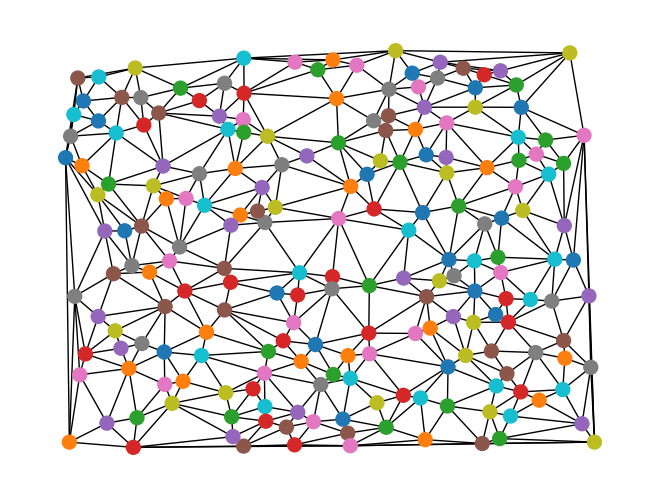

In [55]:
nx.draw(D200, node_color = [equi20color[v] for v in D200], font_size=9, pos=D200pos, node_size=100, cmap=plt.cm.tab10, vmin=0,
    vmax=19)

In [56]:
assert all(equi20color[v] != equi20color[w] for v,w in D200.edges)

In [57]:
nodes_per_color = [0] * 20
for v in equi20color:
    nodes_per_color[equi20color[v]] += 1
print(nodes_per_color)

[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


In [59]:
max([D200.degree(x) for x in D200.nodes])

9

In [198]:
equi22color = equi_color_planar(D20000, 22)

In [175]:
assert all(equi22color[v] != equi22color[w] for v,w in D20000.edges)

In [176]:
nodes_per_color = [0] * (max(equi22color.values())+1)
for v in equi22color:
    nodes_per_color[equi22color[v]] += 1
print(nodes_per_color)

[909, 909, 909, 909, 909, 909, 909, 909, 909, 909, 909, 909, 909, 909, 909, 909, 909, 909, 909, 909, 910, 910]
